### Apresentação

Este notebook tem como objetivo demonstrar a criação de ruídos e diferentes técnicas de suavização em um sinal. Inicialmente, é criado um sinal contínuo e idealizado, que pode ser interpretado como uma propriedade física ao longo do tempo ou da profundidade. Em seguida, é adicionado ruído aleatório ao sinal, simulando incertezas e imperfeições comuns em medições de campo.

Na sequência, são aplicadas duas técnicas clássicas de suavização: a média móvel e o filtro de Savitzky–Golay. Os resultados são comparados com o sinal original, destacando as diferenças no comportamento de cada método, em especial o deslocamento (shift) introduzido pela média móvel e a maior capacidade do Savitzky–Golay em preservar picos, tendências e a forma original do sinal. O objetivo final é mostrar como a escolha do método de suavização impacta diretamente a interpretação física dos dados e a tomada de decisão em aplicações reais.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Criação de dataframe com dados para o eixo (tempo ou profundidade)
df = pd.DataFrame({"x":np.linspace(0, 100, 500)})

# Criação de sinal base sintético (tendência + variação cíclica) para simular um dado real
df["sinal"] = 0.05 * df["x"] + np.sin(0.2 * df["x"])

print("Quantidade de linhas e colunas:", df.shape)
df.head(10)

Quantidade de linhas e colunas: (500, 2)


,x,sinal
0,0.000000,0.000000
1,0.200401,0.050089
2,0.400802,0.100115
3,0.601202,0.150011
4,0.801603,0.199715
5,1.002004,0.249162
6,1.202405,0.298290
7,1.402806,0.347035
8,1.603206,0.395336
9,1.803607,0.443130


Text(0.5, 1.0, 'Sinal (sem ruído)')

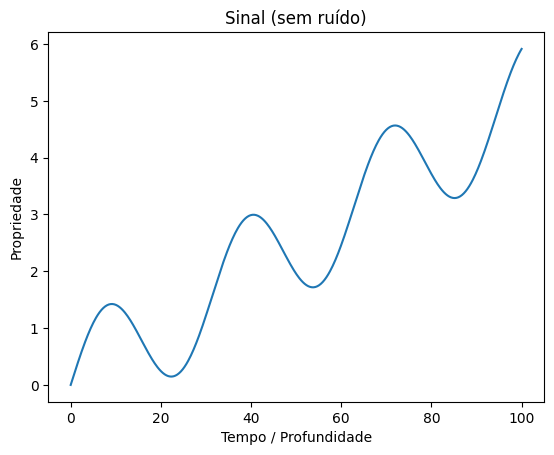

In [3]:
# Plot do sinal
plt.plot(df["x"], df["sinal"])
plt.xlabel("Tempo / Profundidade")
plt.ylabel("Propriedade")
plt.title("Sinal (sem ruído)")


### Ruídos

In [4]:
# Geração de dados aleatórios a partir de uma distribuição normal
np.random.seed(0)
df["ruido"] = np.random.normal(loc=0,           # média da distribuição
                             scale=0.5,       # desvio padrão
                             size=len(df["x"])      # tamanho do dado
                             )

# Criação do sinal com ruído
df["sinal_ruidoso"] = df["sinal"] + df["ruido"]

Text(0.5, 1.0, 'Sinal com ruído (simulação de dado real)')

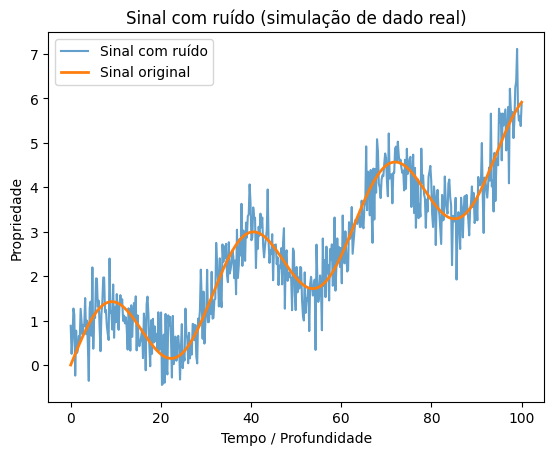

In [5]:
# Plot do sinal ruidoso
plt.plot(df["x"], df["sinal_ruidoso"], label="Sinal com ruído", alpha=0.7)
plt.plot(df["x"], df["sinal"], label="Sinal original", linewidth=2)
plt.legend()
plt.xlabel("Tempo / Profundidade")
plt.ylabel("Propriedade")
plt.title("Sinal com ruído (simulação de dado real)")

### Suavização (média móvel)

Faz a média dos dados baseado em uma janela de N amostras progressivamente.

Text(0.5, 1.0, 'Suavização por média móvel')

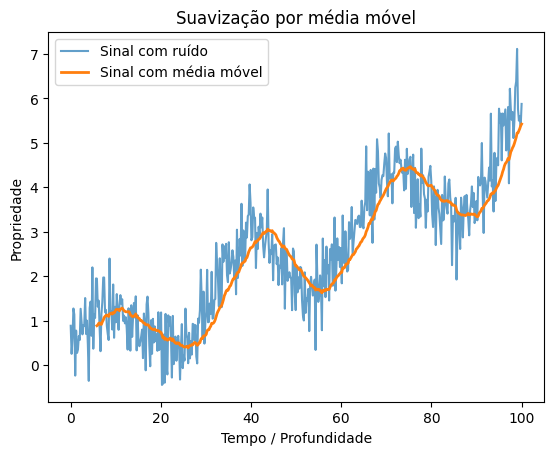

In [6]:
# Criação da média móvel no dado ruidoso (quanto maior a janela, mais suave será o sinal)
df["sinal_mm"] = df["sinal_ruidoso"].rolling(window=30).mean()  # quantidade de amostras para ser considerado uma janela (ex: 30)

plt.plot(df["x"], df["sinal_ruidoso"], alpha=0.7, label="Sinal com ruído")
plt.plot(df["x"], df["sinal_mm"], linewidth=2, label="Sinal com média móvel")
plt.legend()
plt.xlabel("Tempo / Profundidade")
plt.ylabel("Propriedade")
plt.title("Suavização por média móvel")


### Suavização (Savitzky–Golay)

Reduz o ruído ajustando pequenas curvas locais ao sinal, em vez de apenas fazer médias, o que ajuda a manter picos e tendências físicas.

Text(0.5, 1.0, 'Filtro Savitzky–Golay')

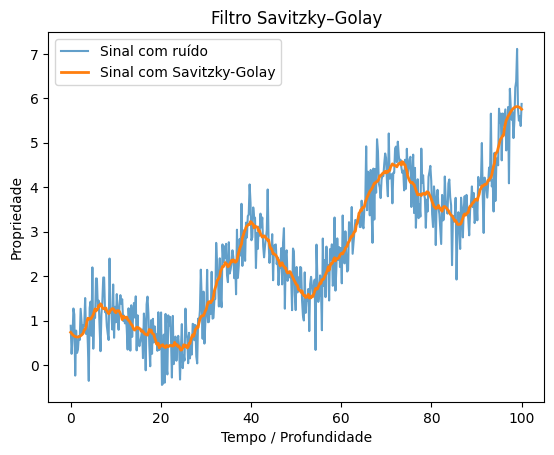

In [7]:
from scipy.signal import savgol_filter

df["sinal_sg"] = savgol_filter(df["sinal_ruidoso"],
                              window_length=30,         # quantidade de amostras para ser considerado uma janela para ajuste
                              polyorder=2)              # ordem do polinômio

plt.plot(df["x"], df["sinal_ruidoso"], alpha=0.7, label="Sinal com ruído")
plt.plot(df["x"], df["sinal_sg"], linewidth=2, label="Sinal com Savitzky-Golay")
plt.legend()
plt.xlabel("Tempo / Profundidade")
plt.ylabel("Propriedade")
plt.title("Filtro Savitzky–Golay")


### Comparação

Text(0.5, 1.0, 'Comparação de sinais')

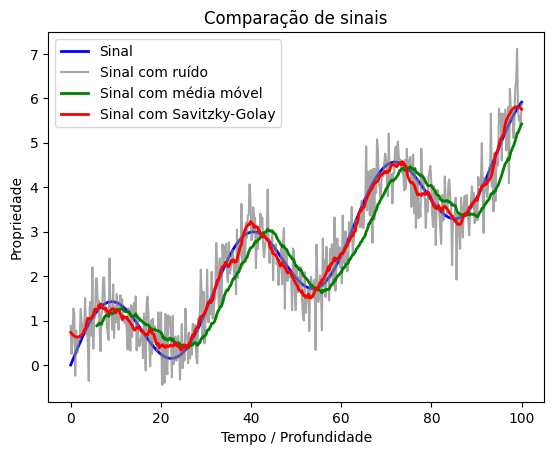

In [8]:
plt.plot(df["x"], df["sinal"], linewidth=2, label="Sinal", color="blue")
plt.plot(df["x"], df["sinal_ruidoso"], alpha=0.7, label="Sinal com ruído", color="gray")
plt.plot(df["x"], df["sinal_mm"], linewidth=2, label="Sinal com média móvel", color="green")
plt.plot(df["x"], df["sinal_sg"], linewidth=2, label="Sinal com Savitzky-Golay", color="red")
plt.legend()
plt.xlabel("Tempo / Profundidade")
plt.ylabel("Propriedade")
plt.title("Comparação de sinais")

### Conclusão

Repare que os métodos de suavização apresentam um ajuste diferente ao sinal original, mesmo colocando janela de amostras semelhantes entre eles. Para a média móvel, você terá um sinal mais deslocado caso vá aumentando o número de janelas. Já o filtro Savitsky-Golay consegue seguir a forma local do sinal, diferente da média, que trata todos os pontos igualmente, ou seja, se existe um pico real, o polinômio "sobe com ele".